# Recitation 12 - Causal Inference

## Part 1: Exploring the Christmas Sales Data

We have data from an online marketplace on toy stores' sales before Christmas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
xmas_sales = pd.read_csv('xmas_sales.csv')
xmas_sales.head(8)

,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1,219.60
1,1,2,12.98,1,184.70
2,1,1,12.98,1,145.75
3,1,0,12.98,0,102.45
4,2,3,19.92,0,103.22
5,2,2,19.92,0,53.73
6,2,1,19.92,0,13.84
7,2,0,19.92,0,0.00


### Data Description

| Column | Description |
| :--- | :--- |
| store | Each store's unique identifier |
| weeks_to_xmas | Weeks before Christmas |
| avg_week_sales | Average products sold per week (indicates size) |
| is_on_sale | Indicator for price drop (treatment) |
| weekly_amount_sold | Average weekly sales during that week (outcome) |

### Task 1: Visualize the Relationship

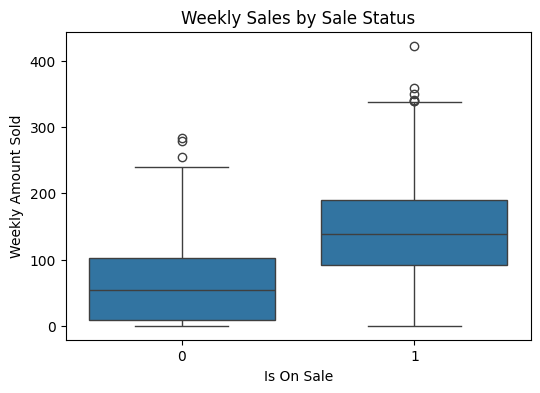

In [3]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_on_sale', y='weekly_amount_sold', data=xmas_sales)
plt.title('Weekly Sales by Sale Status')
plt.xlabel('Is On Sale')
plt.ylabel('Weekly Amount Sold')
plt.show()

**Explanation:**
- Stores on sale sell ~100 units more on average
- However, this is just an **association**, not necessarily causal
- **Selection bias** may exist: larger, more successful stores might be more likely to run sales
- The **fundamental problem of causal inference**: we can't observe the same store with and without sales simultaneously

---

## Part 2: The Management Training Problem

A company implemented manager training to improve employee engagement. The study was not properly randomized.

In [4]:
df = pd.read_csv("management_training.csv")
df.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843


### Data Description

| Column | Description |
| :--- | :--- |
| intervention | Treatment variable (1 = received training) |
| engagement_score | Outcome: average standardized engagement score |
| tenure | Years the manager has been with the company |
| n_of_reports | Number of direct reports |
| gender | Categorical variable for gender |
| role | Job category |
| department_size | Number of employees in department |
| department_score | Average engagement score in department |
| last_engagement_score | Previous engagement score |

### Task 2: Calculate the Naive ATE

In [5]:
mean_treated = df[df["intervention"] == 1]["engagement_score"].mean()
mean_untreated = df[df["intervention"] == 0]["engagement_score"].mean()

naive_ate = mean_treated - mean_untreated
print(f"Mean (Treated): {mean_treated:.4f}")
print(f"Mean (Untreated): {mean_untreated:.4f}")
print(f"Naive ATE: {naive_ate:.4f}")

Mean (Treated): 0.1999
Mean (Untreated): -0.2347
Naive ATE: 0.4346


**Explanation:**
- Naive ATE ≈ **0.43**
- This is "naive" because we simply compare means without adjusting for confounders
- Managers who chose training may already have higher-engaged teams
- This estimate is likely **biased upward** due to self-selection

---

## Part 3: Propensity Score Estimation

The **propensity score** $e(x) = P(T=1|X)$ is the probability of receiving treatment given observed characteristics. It summarizes all confounders into a single number.

### Task 3: Fit a Propensity Score Model

In [6]:
import statsmodels.formula.api as smf

ps_model = smf.logit("""intervention ~ tenure + last_engagement_score + department_score +
                     C(n_of_reports) + C(gender) + C(role)""", data=df).fit(disp=0)

data_ps = df.assign(propensity_score = ps_model.predict(df))
print("Propensity Score Distribution:")
print(data_ps['propensity_score'].describe())

Propensity Score Distribution:
count    10391.000000
mean         0.539987
std          0.116422
min          0.115837
25%          0.471306
50%          0.550060
75%          0.617527
max          0.861661
Name: propensity_score, dtype: float64


In [7]:
data_ps.head(10)

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensity_score
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.580990
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976
5,76,1,0.009607,6,4,2,4,-0.391848,0.224077,843,0.570020
6,76,1,1.743033,6,4,1,4,1.964554,0.224077,843,0.653871
7,76,1,0.953294,6,4,1,4,3.726526,0.224077,843,0.695098
8,76,1,2.367780,6,5,2,4,-0.934017,0.224077,843,0.603470
9,76,1,1.264409,6,4,1,4,0.319088,0.224077,843,0.613147


**Explanation:**
- We use **logistic regression** since treatment is binary
- The propensity score is each manager's probability of receiving training
- Two managers with the same propensity score are comparable—if one got treatment and the other didn't, it's essentially by chance
- `C()` wraps categorical variables in the formula

---

## Part 4: Propensity Score Matching

**Matching** pairs similar treated and untreated units based on propensity scores.

### Task 4: Implement Matching Estimator

In [8]:
from sklearn.neighbors import KNeighborsRegressor

T = "intervention"
X = "propensity_score"
Y = "engagement_score"

# Split data into treated and untreated
treated = data_ps.query(f"{T}==1")
untreated = data_ps.query(f"{T}==0")

print(f"Treated units: {len(treated)}")
print(f"Untreated units: {len(untreated)}")

# Fit KNN models (K=1 nearest neighbor)
mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[[X]], untreated[Y])
mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[[X]], treated[Y])

# Create matched predictions
predicted = pd.concat([
    treated.assign(match=mt0.predict(treated[[X]])),   # treated matched to untreated
    untreated.assign(match=mt1.predict(untreated[[X]])) # untreated matched to treated
])

Treated units: 5611
Untreated units: 4780


In [9]:
predicted[['engagement_score', 'propensity_score', 'intervention', 'match']].head()

,engagement_score,propensity_score,intervention,match
0,0.277359,0.596106,1,0.557680
1,-0.449646,0.391138,1,-0.952622
2,0.769703,0.602578,1,-0.618381
3,-0.121763,0.580990,1,-1.404962
4,1.526147,0.619976,1,0.000354


**Explanation:**
- For each treated unit, we find the untreated unit with the closest propensity score
- For each untreated unit, we find the treated unit with the closest propensity score
- The `match` column contains the outcome of the matched unit (our counterfactual estimate)

### Task 4b: Calculate the ATE using Matching

In [10]:
# For treated: effect = outcome - match
# For untreated: effect = match - outcome
matching_ate = np.mean(
    (predicted[Y] - predicted["match"]) * predicted[T] +
    (predicted["match"] - predicted[Y]) * (1 - predicted[T])
)

print(f"Matching ATE: {matching_ate:.4f}")

Matching ATE: 0.2878


**Explanation:**
- Matching ATE ≈ **0.29** (vs Naive 0.43)
- The formula calculates individual treatment effects:
  - For treated: `outcome - match` (what happened vs. counterfactual)
  - For untreated: `match - outcome` (counterfactual vs. what happened)
- We then average these individual effects

---

## Part 5: Inverse Propensity Weighting (IPW)

**IPW** creates a pseudo-population where treatment appears randomized by reweighting observations.

$$ATE = E\Big(\frac{1(T=1)Y}{e(x)}\Big) - E\Big(\frac{1(T=0)Y}{1-e(x)}\Big)$$

### Task 5: Implement IPW Estimator

In [11]:
# Calculate weights
weight_t = 1 / data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1 / (1 - data_ps.query("intervention==0")["propensity_score"])

# Get outcomes
y_treated = data_ps.query("intervention==1")["engagement_score"]
y_untreated = data_ps.query("intervention==0")["engagement_score"]

# Calculate weighted averages
n = len(data_ps)
E_Y1 = sum(y_treated * weight_t) / n
E_Y0 = sum(y_untreated * weight_nt) / n

ipw_ate = E_Y1 - E_Y0

print(f"E[Y1] (everyone treated): {E_Y1:.4f}")
print(f"E[Y0] (everyone untreated): {E_Y0:.4f}")
print(f"IPW ATE: {ipw_ate:.4f}")

E[Y1] (everyone treated): 0.1166
E[Y0] (everyone untreated): -0.1494
IPW ATE: 0.2660


**Explanation:**
- IPW ATE ≈ **0.27**
- **Intuition:**
  - Treated with low propensity: "surprising" cases → high weight (informative about untreated-like people when treated)
  - Untreated with high propensity: also "surprising" → high weight (informative about treated-like people when untreated)
- **Caution:** Can have high variance if propensity scores are near 0 or 1

---

## Part 6: Potential Outcome Modelling (POM)

**POM** builds separate predictive models for each treatment condition.

### Task 6: Implement POM Estimator

In [12]:
from sklearn.linear_model import LinearRegression
from patsy import dmatrix

def pom(df, formula, T, Y):
    """Potential Outcome Modelling estimator."""
    # Create design matrix
    X = dmatrix(formula, df)

    # Fit separate models for each treatment condition
    m0 = LinearRegression().fit(X[df[T]==0, :], df.query(f"{T}==0")[Y])
    m1 = LinearRegression().fit(X[df[T]==1, :], df.query(f"{T}==1")[Y])

    # Predict potential outcomes for ALL units
    m0_hat = m0.predict(X)  # outcome if untreated
    m1_hat = m1.predict(X)  # outcome if treated

    # ATE = average difference in potential outcomes
    ate = np.mean(m1_hat) - np.mean(m0_hat)

    return pd.DataFrame({'m0': m0_hat, 'm1': m1_hat}), ate

In [13]:
formula = """tenure + last_engagement_score + department_score + C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

pom_df, pom_ate = pom(df, formula, T, Y)

print(f"POM ATE: {pom_ate:.4f}")
print("\nSample potential outcomes (m0=untreated, m1=treated):")
print(pom_df.head())

POM ATE: 0.2669

Sample potential outcomes (m0=untreated, m1=treated):
         m0        m1
0 -0.013219  0.351869
1 -0.576179 -0.340403
2 -0.016198  0.350848
3 -0.006321  0.354233
4  0.253332  0.622939


**Explanation:**
- POM ATE ≈ **0.27**
- **Steps:**
  1. Model m0: trained only on untreated data
  2. Model m1: trained only on treated data
  3. Predict what each person's outcome would be under both scenarios
  4. ATE = mean(m1 predictions) - mean(m0 predictions)
- Individual treatment effects can be computed as: `m1 - m0` for each person

---

## Summary: Compare All ATE Estimates

In [14]:
print("="*50)
print("SUMMARY OF ATE ESTIMATES")
print("="*50)
print(f"{'Method':<35} {'ATE':>10}")
print("-"*50)
print(f"{'Naive (no adjustment)':<35} {naive_ate:>10.4f}")
print(f"{'Propensity Score Matching':<35} {matching_ate:>10.4f}")
print(f"{'Inverse Propensity Weighting':<35} {ipw_ate:>10.4f}")
print(f"{'Potential Outcome Modelling':<35} {pom_ate:>10.4f}")
print("="*50)

SUMMARY OF ATE ESTIMATES
Method                                     ATE
--------------------------------------------------
Naive (no adjustment)                   0.4346
Propensity Score Matching               0.2878
Inverse Propensity Weighting            0.2660
Potential Outcome Modelling             0.2669


### Key Takeaways

**1. Why are causal estimates smaller than naive?**
- The naive estimate suffers from **selection bias**
- Managers who got training already had better characteristics
- All three causal methods adjust for this and give similar answers (~0.27)

**2. Method comparison:**
| Method | Pros | Cons |
|--------|------|------|
| Matching | Intuitive, transparent | May discard data, depends on match quality |
| IPW | Uses all data | High variance with extreme weights |
| POM | Flexible, can detect heterogeneous effects | Relies on correct outcome model |

**3. Key assumptions:**
- **Unconfoundedness:** No unmeasured confounders
- **Positivity:** 0 < P(T=1|X) < 1 for all X
- **SUTVA:** No interference, single version of treatment

**Bottom line:** Training improves engagement by ~0.27 standard deviations—meaningful, but ~40% smaller than the naive estimate suggested!